In [1]:
import pickle

with open("stats/crowded_ultimate.pkl", "rb") as f:
    crowded = pickle.load(f)

with open("stats/daytime_ultimate.pkl", "rb") as f:
    daytime = pickle.load(f)

with open("stats/weather_ultimate.pkl", "rb") as f:
    weather = pickle.load(f)

with open("stats/indoor_outdoor_ultimate.pkl", "rb") as f:
    indoor_outdoor = pickle.load(f)

print('CROWDED')
crowded_total = len(crowded[0]) + len(crowded[1]) + len(crowded[2]) + len(crowded[3]) 
print("EMPTY", len(crowded[0])/crowded_total)
print("SCATERED", len(crowded[1])/crowded_total)
print("MODERATE", len(crowded[2])/crowded_total)
print("CROWDED",len(crowded[3])/crowded_total)

print('DAYTIME')
daytime_total = len(daytime[0]) + len(daytime[1]) 
print("DAY", len(daytime[0])/daytime_total)
print("NIGHT", len(daytime[1])/daytime_total)

print('INDOOR_OUTDOOR')
indoor_outdoor_total = len(indoor_outdoor[0]) + len(indoor_outdoor[1]) 
print("INDOOR", len(indoor_outdoor[0])/indoor_outdoor_total)
print("OUTDOOR", len(indoor_outdoor[1])/indoor_outdoor_total)


print('WEATHER')
weather_total = len(weather[0]) + len(weather[1])+ len(weather[2])+ len(weather[3]) 
print("SUNNY", len(weather[0])/weather_total)
print("RAINY", len(weather[1])/weather_total)
print("CLOUDY", len(weather[2])/weather_total)
print("SNOWY", len(weather[3])/weather_total)

CROWDED
EMPTY 0.14479025710419485
SCATERED 0.4225304465493911
MODERATE 0.3688261163734777
CROWDED 0.0638531799729364
DAYTIME
DAY 0.836180649526387
NIGHT 0.16381935047361298
INDOOR_OUTDOOR
INDOOR 0.11713464140730717
OUTDOOR 0.8828653585926928
WEATHER
SUNNY 0.5378044654939107
RAINY 0.07307171853856563
CLOUDY 0.3499661705006766
SNOWY 0.039157645466847094


In [2]:
country_to_region_globe = {
    "United Kingdom": "Anglo",
    "Belgium": "Germanic Europe",
    "Ireland": "Anglo",
    "France": "Latin Europe",
    "Germany": "Germanic Europe",
    "Portugal": "Latin Europe",
    "Spain": "Latin Europe",
    "Italy": "Latin Europe",
    "Switzerland": "Latin Europe",
    "Netherlands": "Germanic Europe",
    "Austria": "Germanic Europe",
    "Malta": "Latin Europe",
    "Denmark": "Nordic Europe",
    "Norway": "Nordic Europe",
    "Sweden": "Nordic Europe",
    "Finland": "Nordic Europe",
    "Iceland": "Nordic Europe",
    "Greece": "Eastern Europe",
    "Poland": "Eastern Europe",
    "Czech Republic": "Eastern Europe",
    "Slovakia": "Eastern Europe",
    "Hungary": "Eastern Europe",
    "Romania": "Latin Europe",
    "Belarus": "Eastern Europe",
    "Serbia": "Eastern Europe",
    "Moldova": "Latin Europe",
    "Estonia": "Nordic Europe",
    "Latvia": "Nordic Europe",
    "United States": "Anglo",
    "Canada": "Anglo",
    "Bermuda": "Other",
    "Mexico": "Latin America",
    "Brazil": "Latin America",
    "Chile": "Latin America",
    "Peru": "Latin America",
    "Uruguay": "Latin America",
    "Paraguay": "Latin America",
    "Colombia": "Latin America",
    "Costa Rica": "Latin America",
    "Venezuela": "Latin America",
    "Jamaica": "African",
    "Barbados": "African",
    "Antigua and Barbuda": "African",
    "Saint Lucia": "Other",
    "Kenya": "African",
    "Malawi": "African",
    "South African": "African",
    "Nigeria": "African",
    "Ghana": "African",
    "Senegal": "African",
    "Benin": "African",
    "Madagascar": "African",
    "Ethiopia": "African",
    "Eritrea": "African",
    "Mali": "African",
    "Gambia": "African",
    "United Arab Emirates": "Middle East",
    "Jordan": "Middle East",
    "Syria": "Middle East",
    "Iraq": "Middle East",
    "Lebanon": "Middle East",
    "Egypt": "Middle East",
    "Morocco": "Middle East",
    "Kuwait": "Middle East",
    "Israel": "Latin Europe",
    "Turkey": "Middle East",
    "Afghanistan": "South-East Asia",
    "India": "South-East Asia",
    "Pakistan": "South-East Asia",
    "Bangladesh": "South-East Asia",
    "Sri Lanka": "South-East Asia",
    "Nepal": "South-East Asia",
    "China": "Confucian Asia",
    "Japan": "Confucian Asia",
    "South Korea": "Confucian Asia",
    "Taiwan": "Confucian Asia",
    "Thailand": "South-East Asia",
    "Vietnam": "Confucian Asia",
    "Indonesia": "South-East Asia",
    "Singapore": "Confucian Asia",
    "Brunei": "South-East Asia",
    "Kazakhstan": "Eastern Europe",
    "Kyrgyzstan": "Eastern Europe",
    "Tajikistan": "South-East Asia",
    "Azerbaijan": "Middle East",
    "Georgia": "Eastern Europe",
    "Australia": "Anglo",
    "New Zealand": "Anglo",
    "Samoa": "South-East Asia",
    "Holy See": "Other",
    "South Africa": "African"
}

In [18]:
import glob
import matplotlib.pyplot as plt
import json
import cv2
import numpy as np
import pickle
from collections import defaultdict

path = '../SEKAI_900_3/videos_frames'

files = glob.glob(f'{path}/*')

#print(files)
countries = defaultdict(int)
cities = defaultdict(int)
origin = []


sekai, ours = 0, 0

country_mapping = {
    "USA": "United States",
    "UAE": "United Arab Emirates",
    "Korea": "South Korea",
    "Czechia": "Czech Republic",
}

regions_to_clip_ids = defaultdict(list)
clip_to_region = {}
files.sort()

for file_id, file in enumerate(files):
    
    #print(file)
    path = file.split('/')[-1]
    with open(f'{file.replace('videos_frames','jsons_step1')}.json', 'r') as f:
        data = json.load(f)
    
    country = data['country']
    city = data['city']
    origin.append(data['source'])
    if data['dataset'] == 'sekai':
        sekai+=1
    else:
        ours+=1

    if country in country_mapping.keys():
        country = country_mapping[country]

    regions_to_clip_ids[country_to_region_globe[country]].append(file_id + (180 if file_id > 180 else 0))
    
    cities[data['city']]+=1
    countries[country]+=1
    
    clip_to_region[path] = country_to_region_globe[country] 
    #print(country_to_region_globe[country])



with open('clip_to_region.pkl','wb') as f:
    pickle.dump(clip_to_region, f)

print('Number of countries:', len(countries))
print('Number of cities:', len(cities))


print(sekai)
print(ours)

print('Sekai (%)', sekai/(sekai+ours))
print('Number of clips (Sekai):', sekai)

print('Ours (%)', ours/(sekai+ours))
print('Number of clips (Ours):', ours)


print('')
print('Region to clip IDs:')
print(regions_to_clip_ids)

Number of countries: 74
Number of cities: 152
631
269
Sekai (%) 0.7011111111111111
Number of clips (Sekai): 631
Ours (%) 0.29888888888888887
Number of clips (Ours): 269

Region to clip IDs:
defaultdict(<class 'list'>, {'African': [0, 24, 26, 39, 55, 72, 83, 91, 95, 96, 108, 110, 114, 120, 127, 131, 134, 137, 138, 139, 142, 146, 148, 153, 158, 174, 363, 370, 376, 379, 388, 393, 394, 406, 417, 436, 442, 447, 448, 449, 477, 483, 490, 503, 520, 531, 539, 694, 849, 872, 875, 878, 883, 889, 902, 911, 979, 988, 991, 994, 995, 1000, 1001, 1010, 1012, 1021, 1030, 1042, 1048, 1054, 1055, 1057, 1063, 1075, 1076], 'Anglo': [1, 2, 5, 7, 15, 19, 20, 23, 35, 37, 38, 40, 41, 45, 48, 49, 50, 52, 56, 58, 59, 62, 68, 70, 71, 73, 76, 77, 79, 80, 87, 92, 93, 98, 103, 150, 151, 152, 155, 157, 171, 548, 553, 554, 556, 560, 563, 564, 566, 569, 571, 577, 582, 583, 584, 587, 589, 591, 595, 597, 598, 602, 608, 612, 614, 616, 617, 619, 623, 630, 631, 632, 635, 636, 641, 644, 647, 649, 650, 653, 655, 656, 661, 662

{'United Kingdom': 88, 'Germany': 61, 'United States': 54, 'United Arab Emirates': 47, 'Japan': 42, 'China': 38, 'Kenya': 37, 'Italy': 31, 'Pakistan': 24, 'Poland': 24, 'South Korea': 23, 'Portugal': 20, 'Estonia': 18, 'Chile': 18, 'Latvia': 16, 'France': 15, 'Switzerland': 14, 'Norway': 14, 'Thailand': 14, 'Ethiopia': 14, 'Peru': 14, 'Afghanistan': 13, 'Belarus': 13, 'Nepal': 13, 'Brazil': 11, 'Finland': 11, 'Uruguay': 10, 'Indonesia': 10, 'Holy See': 9, 'Iceland': 9, 'Egypt': 8, 'Hungary': 8, 'Costa Rica': 8, 'Canada': 8, 'Nigeria': 8, 'Belgium': 8, 'New Zealand': 6, 'Colombia': 6, 'Taiwan': 6, 'Malta': 6, 'Georgia': 6, 'Kuwait': 6, 'Morocco': 6, 'Barbados': 6, 'Mexico': 5, 'Azerbaijan': 5, 'Iraq': 5, 'Sweden': 4, 'Greece': 4, 'Czech Republic': 4, 'Jordan': 4, 'Kyrgyzstan': 4, 'Singapore': 4, 'Israel': 3, 'Jamaica': 3, 'Serbia': 3, 'Australia': 3, 'Venezuela': 3, 'South Africa': 3, 'Sri Lanka': 2, 'India': 2, 'Tajikistan': 2, 'Kazakhstan': 2, 'Ireland': 2, 'Gambia': 2, 'Syria': 2, 'S

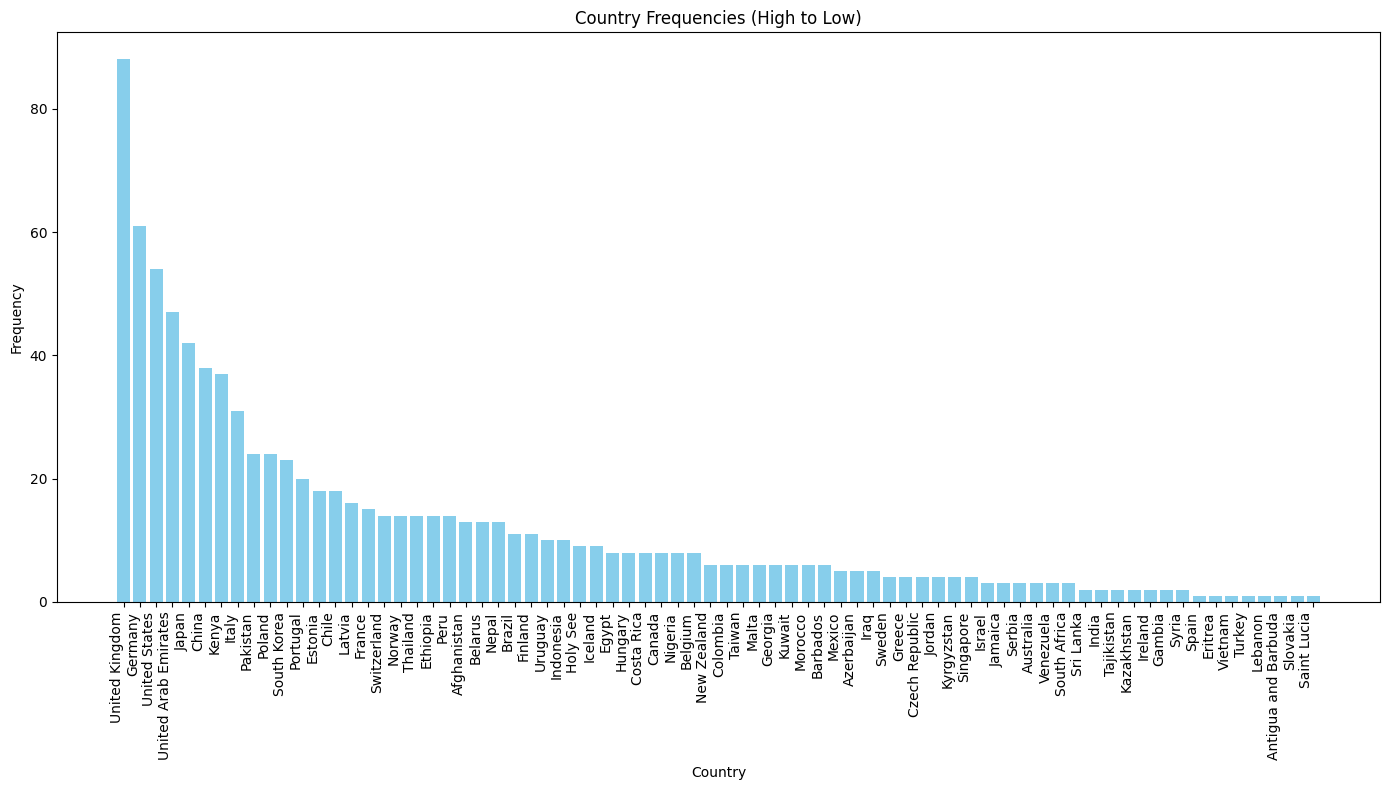

In [4]:
#print(countries)

sorted_data = dict(sorted(countries.items(), key=lambda item: item[1], reverse=True))

print(sorted_data)
# Step 3: Plot
plt.figure(figsize=(14, 8))
plt.bar(sorted_data.keys(), sorted_data.values(), color='skyblue')
plt.xticks(rotation=90, ha='right')
plt.xlabel("Country")
plt.ylabel("Frequency")
plt.title("Country Frequencies (High to Low)")
plt.tight_layout()
plt.show()

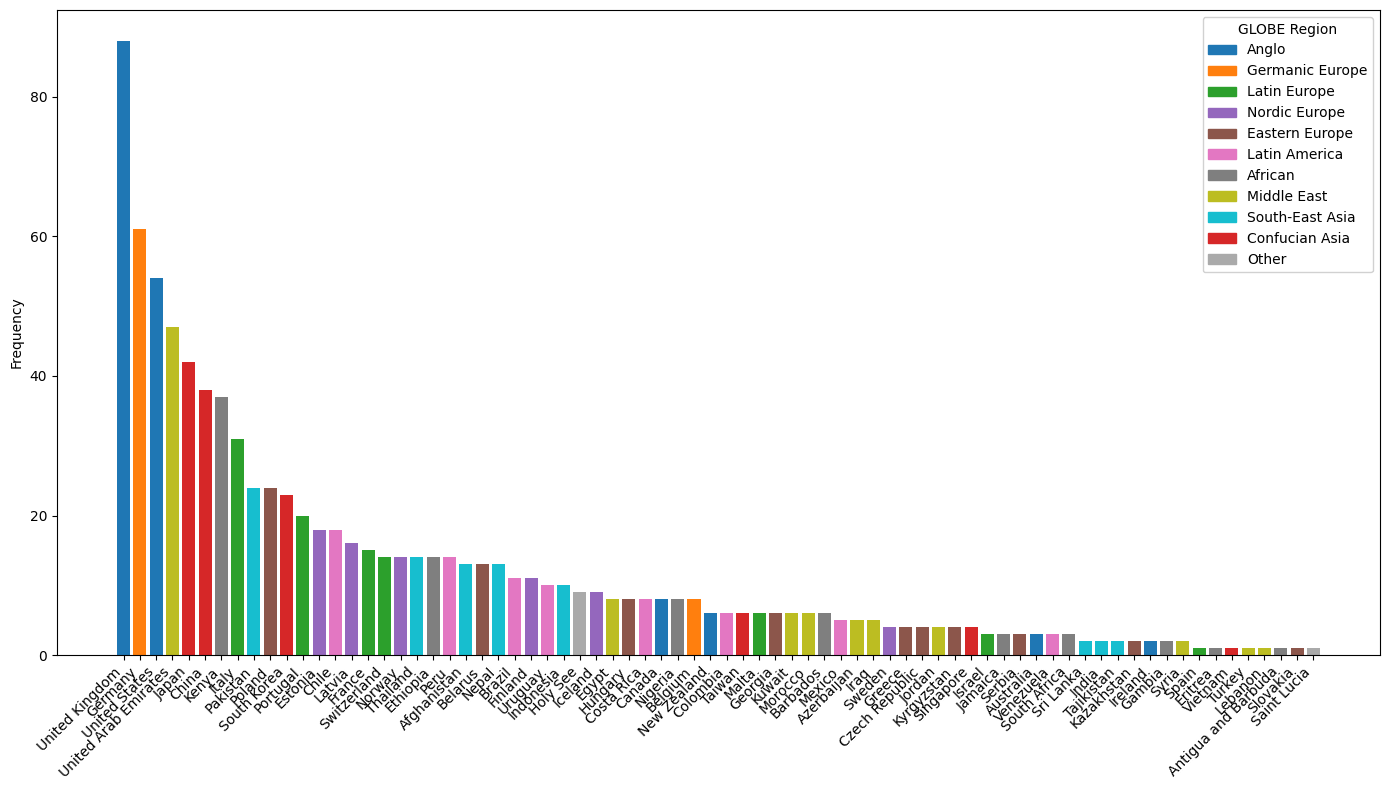

In [5]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# Sort countries by frequency
countries = dict(sorted(countries.items(), key=lambda item: item[1], reverse=True))
# Region → color mapping
region_colors = {
    "Anglo": "#1f77b4",
    "Germanic Europe": "#ff7f0e",
    "Latin Europe": "#2ca02c",
    "Nordic Europe": "#9467bd",
    "Eastern Europe": "#8c564b",
    "Latin America": "#e377c2",
    "African": "#7f7f7f",
    "Middle East": "#bcbd22",
    "South-East Asia": "#17becf",
    "Confucian Asia": "#d62728",
    "Other": "#aaaaaa"
}

# Create color list aligned with sorted countries
bar_colors = [
    region_colors.get(country_to_region_globe.get(country, "Other"), "#aaaaaa")
    for country in countries.keys()
]

# Plot
plt.figure(figsize=(14, 8))
plt.bar(countries.keys(), countries.values(), color=bar_colors)

plt.xticks(rotation=45, ha='right')
#plt.xlabel("Country")
plt.ylabel("Frequency")
#plt.title("Country Frequencies Colored by GLOBE Cultural Region")

legend_handles = [
    mpatches.Patch(color=color, label=region)
    for region, color in region_colors.items()
]

plt.legend(
    handles=legend_handles,
    title="GLOBE Region",
    loc="upper right",
    framealpha=0.9
)

plt.savefig(
    "../results/country_frequencies.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

{'Anglo': 161, 'Confucian Asia': 114, 'Latin Europe': 90, 'Middle East': 85, 'South-East Asia': 80, 'African': 75, 'Latin America': 75, 'Nordic Europe': 72, 'Germanic Europe': 69, 'Eastern Europe': 69, 'Other': 10}


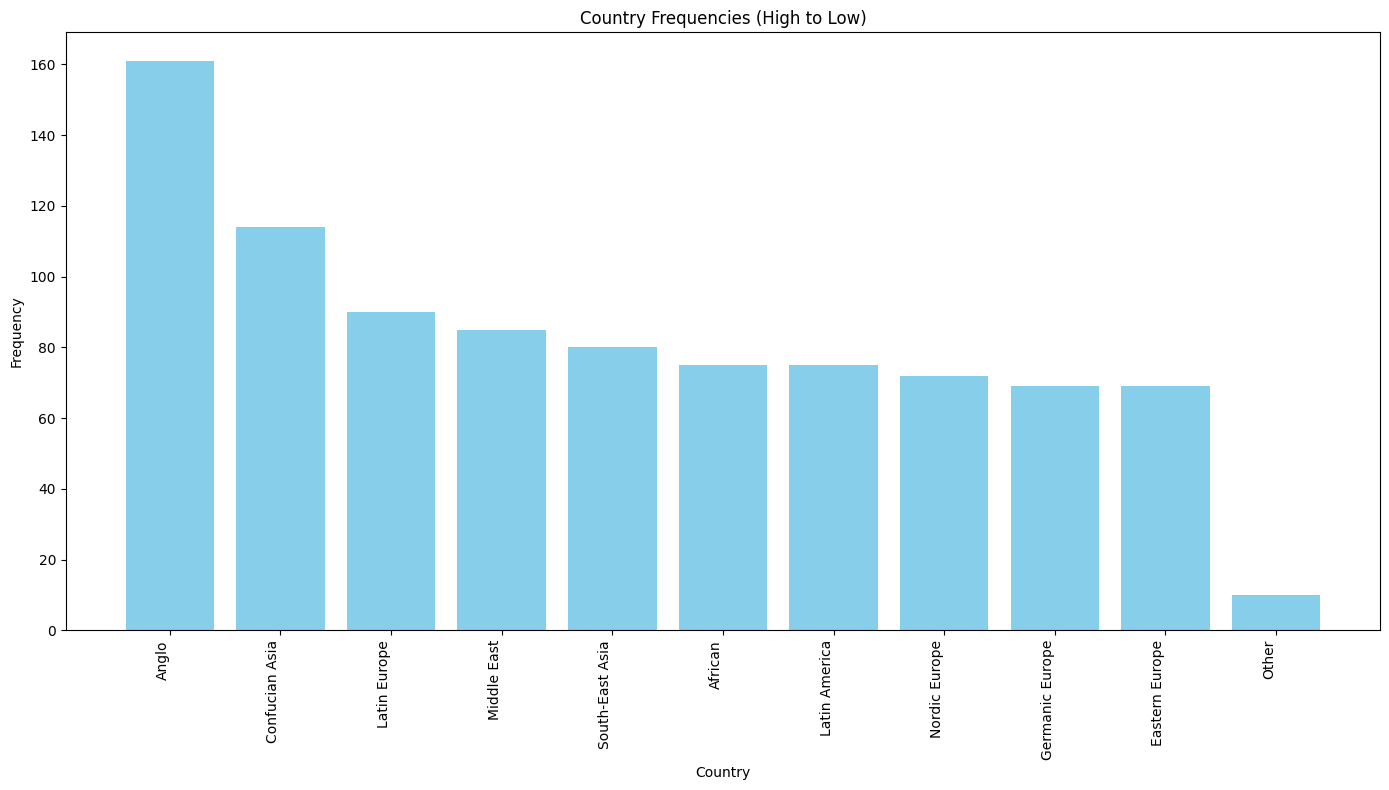

In [6]:
regions = defaultdict(int)
#print(countries)
for country in countries:
    regions[country_to_region_globe[country]]+=countries[country]
    
sorted_data = dict(sorted(regions.items(), key=lambda item: item[1], reverse=True))

print(sorted_data)
# Step 3: Plot
plt.figure(figsize=(14, 8))
plt.bar(sorted_data.keys(), sorted_data.values(), color='skyblue')
plt.xticks(rotation=90, ha='right')
plt.xlabel("Country")
plt.ylabel("Frequency")
plt.title("Country Frequencies (High to Low)")
plt.tight_layout()
plt.show()

In [7]:
import statistics
total = sum(sorted_data.values())

# Percentages
percentages = {k: (v / total) * 100 for k, v in sorted_data.items()}

# Mean and median
values = list(sorted_data.values())
mean_val = statistics.mean(values)
median_val = statistics.median(values)

# Print table
print(f"{'Region':20} {'Count':>6} {'Percent':>10}")
print("-" * 40)

for region, count in sorted(sorted_data.items(), key=lambda x: x[1], reverse=True):
    print(f"{region:20} {count:6d} {percentages[region]:9.2f}%")

print("\nSummary Statistics")
print("-" * 20)
print(f"Total samples: {total}")
print(f"Number of categories: {len(sorted_data)}")
print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val}")

Region                Count    Percent
----------------------------------------
Anglo                   161     17.89%
Confucian Asia          114     12.67%
Latin Europe             90     10.00%
Middle East              85      9.44%
South-East Asia          80      8.89%
African                  75      8.33%
Latin America            75      8.33%
Nordic Europe            72      8.00%
Germanic Europe          69      7.67%
Eastern Europe           69      7.67%
Other                    10      1.11%

Summary Statistics
--------------------
Total samples: 900
Number of categories: 11
Mean: 81.82
Median: 75


In [8]:
print(sorted_data)

{'Anglo': 161, 'Confucian Asia': 114, 'Latin Europe': 90, 'Middle East': 85, 'South-East Asia': 80, 'African': 75, 'Latin America': 75, 'Nordic Europe': 72, 'Germanic Europe': 69, 'Eastern Europe': 69, 'Other': 10}


/tmp/ipykernel_15008/3057390151.py:6: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = go.Figure(go.Choropleth(


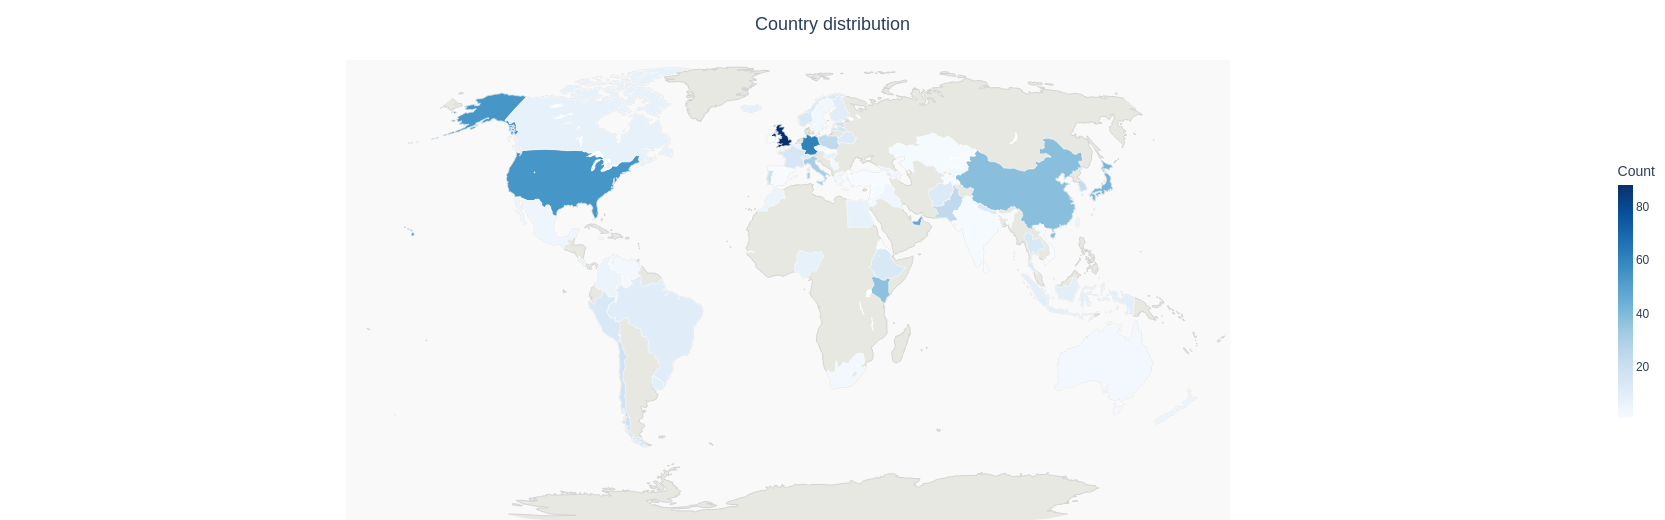

In [9]:
import plotly.graph_objects as go

paises = list(countries.keys())
values = list(countries.values())

fig = go.Figure(go.Choropleth(
    locations=paises,
    locationmode='country names',
    z=values,
    text=[f"{c}: {v}" for c, v in zip(paises, values)],
    hovertemplate='<b>%{text}</b><extra></extra>',
    colorscale='Blues',
    colorbar=dict(title='Count', thickness=15, len=0.6),
    marker_line_color='white',
    marker_line_width=0.5,
))

fig.update_layout(
    title=dict(text='Country distribution', font_size=18, x=0.5, xanchor='center'),
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='lightgray',
        projection_type='natural earth',
        bgcolor='#f9f9f9',
        landcolor='#e8e8e2',
        showland=True,
    ),
    paper_bgcolor='white',
    margin=dict(l=0, r=0, t=60, b=0),
    height=520,
)

fig.show()
# To save as HTML instead:
# fig.write_html('world_map.html')

In [10]:
crowded_subset = [[c for c in crowd if c in origin] for crowd in crowded ]
daytime_subset = [[d for d in day if d in origin] for day in daytime ]
indoor_outdoor_subset = [[i_o for i_o in I_O if i_o in origin] for I_O in indoor_outdoor ]
weather_subset = [[w for w in W if w in origin] for W in weather ]

print('CROWDED')
crowded_total = len(crowded_subset[0]) + len(crowded_subset[1]) + len(crowded_subset[2]) + len(crowded_subset[3]) 
print("EMPTY", len(crowded_subset[0])/crowded_total)
print("SCATERED", len(crowded_subset[1])/crowded_total)
print("MODERATE", len(crowded_subset[2])/crowded_total)
print("CROWDED",len(crowded_subset[3])/crowded_total)

print('DAYTIME')
daytime_total = len(daytime_subset[0]) + len(daytime_subset[1]) 
print("DAY", len(daytime_subset[0])/daytime_total)
print("NIGHT", len(daytime_subset[1])/daytime_total)

print('INDOOR_OUTDOOR')
indoor_outdoor_total = len(indoor_outdoor_subset[0]) + len(indoor_outdoor_subset[1]) 
print("INDOOR", len(indoor_outdoor_subset[0])/indoor_outdoor_total)
print("OUTDOOR", len(indoor_outdoor_subset[1])/indoor_outdoor_total)

print('WEATHER')
weather_total = len(weather_subset[0]) + len(weather_subset[1])+ len(weather_subset[2])+ len(weather_subset[3]) 
print("SUNNY", len(weather_subset[0])/weather_total)
print("RAINY", len(weather_subset[1])/weather_total)
print("CLOUDY", len(weather_subset[2])/weather_total)
print("SNOWY", len(weather_subset[3])/weather_total)

CROWDED
EMPTY 0.0
SCATERED 0.3333333333333333
MODERATE 0.3333333333333333
CROWDED 0.3333333333333333
DAYTIME
DAY 0.8022222222222222
NIGHT 0.19777777777777777
INDOOR_OUTDOOR
INDOOR 0.1411111111111111
OUTDOOR 0.8588888888888889
WEATHER
SUNNY 0.5344444444444445
RAINY 0.07
CLOUDY 0.3611111111111111
SNOWY 0.034444444444444444
